<a href="https://colab.research.google.com/github/adnacicko/StudyBuddy/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dependencies and imports for PDF processing and NLP analysis**

 **SECTION 1: DEPENDENCIES & IMPORTS**

This cell installs all required third-party libraries and imports all standard + third-party modules used throughout the notebook.

Libraries installed:
   - PyPDF2 / pdfplumber : PDF text extraction
   - spacy (en_core_web_sm): NLP pipeline for sentence tokenisation,
     dependency parsing, named-entity recognition
   - language-tool-python : grammar checking (used in the evaluation step)
   - transformers / torch / sentence-transformers / keybert : BERT-based models for embeddings and keyword extraction
   - nltk (punkt, stopwords, averaged_perceptron_tagger): tokenisation
     utilities and stopword lists
   - matplotlib / seaborn / numpy / pandas : visualisation & data handling

NOTE: Run this cell once per Colab session; re-running is harmless.

In [ ]:
!pip install PyPDF2 nltk
!pip install pdfplumber
!pip install spacy
!pip install language-tool-python
!python -m spacy download en_core_web_sm
!pip install transformers torch sentence-transformers keybert

from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM
import torch
from sentence_transformers import SentenceTransformer
import numpy as np

import pdfplumber
import spacy
import re

import PyPDF2
import nltk
from collections import Counter
import string
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import language_tool_python

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk import FreqDist
from nltk.util import ngrams

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 74.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


**USING SPACY FOR SENTENCE TOKENIZATION**

**SECTION 2: PDF TEXT EXTRACTION**

    extract_text_from_pdf(pdf_path)

Opens the PDF at *pdf_path* with pdfplumber and iterates over every page,  concatenating the extracted plain text into a single string.

Page-level character counts are printed as a progress indicator.

Returns:
       
str – the concatenated raw text of the entire document, or an empty string if the file cannot be opened.

In [ ]:
def extract_text_from_pdf(pdf_path):
    text = ""
    try:
        with pdfplumber.open(pdf_path) as pdf:
            print(f"Number of pages: {len(pdf.pages)}")

            for i, page in enumerate(pdf.pages, 1):
                page_text = page.extract_text()
                if page_text:
                    text += page_text + "\n"
                print(f"Extracted page {i}: {len(page_text)} characters")

    except Exception as e:
        print(f"Error reading PDF with pdfplumber: {e}")

    return text

**SECTION 3: TEXT CLEANING UTILITIES**

A layered set of cleaning functions applied in sequence:

    clean_for_spacy(text)
Pre-processes the raw PDF text before spaCy tokenisation.
Collapses repeated whitespace / newlines / tabs and strips common
bullet-point symbols (•, -, *, ·, ●, ▪, ➢, ○, ■, ►, §, →).

    clean_sentence_after_tokenization(sentence)
Post-tokenisation normalisation: lower-cases the sentence, removes
bullet-point characters again (some may survive spaCy), and collapses whitespace.

    clean_sentence_formatting(sentence)
Higher-level formatting pass:
   - strips standalone numbers
   - normalises colon sequences to a single colon
   - collapses whitespace
   - ensures a space after sentence-ending punctuation / colons
   - splits on sentence terminators, capitalises each fragment, then
     re-joins with '. '
   - appends a final '.' if the sentence does not already end in one.

    final_clean_sentences(sentences)
   Applies clean_sentence_formatting() to every sentence and then filters
   by length (6–30 words) and punctuation (must end with '.' or '!').
   Returns the list of surviving clean sentences.


In [ ]:
def clean_for_spacy(text):
    text = re.sub(r' +', ' ', text)
    text = re.sub(r'\n+', '\n', text)
    text = re.sub(r'\t+', ' ', text)
    text = re.sub(r'[•\-*·●▪➢○■►§→]', ' ', text)
    text = re.sub(r' +', ' ', text)
    return text.strip()

def clean_sentence_after_tokenization(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r'[•\-*·●▪➢○■►§→]', ' ', sentence)
    sentence = re.sub(r' +', ' ', sentence)
    sentence = sentence.strip()
    return sentence

def clean_sentence_formatting(sentence):
    sentence = re.sub(r'\b\d+\b', '', sentence)
    sentence = re.sub(r':+', ':', sentence)
    sentence = re.sub(r'\s+', ' ', sentence)
    sentence = re.sub(r'\.([a-zA-Z])', r'. \1', sentence)
    sentence = re.sub(r':([a-zA-Z])', r': \1', sentence)

    sentences = re.split(r'[.!?]', sentence)
    cleaned_parts = []

    for part in sentences:
        part = part.strip()
        if part:
            if part and part[0].islower():
                part = part[0].upper() + part[1:]
            cleaned_parts.append(part)

    sentence = '. '.join(cleaned_parts)
    if sentence and not sentence.endswith('.'):
        sentence += '.'

    return sentence.strip()

def final_clean_sentences(sentences):
    cleaned = []

    for sentence in sentences:
        sentence = clean_sentence_formatting(sentence)
        sentence = re.sub(r'\s+', ' ', sentence).strip()

        words = sentence.split()
        if (6 <= len(words) <= 30 and
            any(sentence.endswith(p) for p in ['.', '!']) and
            not sentence.endswith('?')):
            cleaned.append(sentence)

    return cleaned

**SECTION 4: SENTENCE QUALITY FILTERS**

Boolean predicates used to accept or reject candidate sentences:

    is_meaningful_sentence(sentence)
   Accepts sentences that are 5–50 words long, do NOT end with '?', and
   DO end with '.' or '!'.  Used as the first-pass filter right after
   spaCy tokenisation.

    is_heading_sentence(sentence)
   Detects short fragment-style headings (≤4 words), sentences ending with
   ':', or strings containing typical section-heading keywords such as
   'generation', 'layer:', 'vs.', 'include:'.
   Headings are candidates for merging with the following sentence.

    is_definition_heading(sentence)
   Identifies definition-style headings: short (≤6 words) and containing
   patterns like ': a', ': the', 'defined as', 'refers to', etc.

    is_good_quality(sentence)
   Stricter check used in the merging stage:
   - 4–35 words
   - ends with '.' or '!'
   - is not a lone number or abbreviation pattern
   - contains at least 3 content words (length > 2).


In [ ]:
def is_meaningful_sentence(sentence):
    words = sentence.split()
    if len(words) < 5 or len(words) > 50:
        return False
    if sentence.strip().endswith('?'):
        return False
    if not any(sentence.endswith(p) for p in ['.', '!']):
        return False
    return True

def is_heading_sentence(sentence):
    words = sentence.split()
    if len(words) <= 4:
        return True
    if sentence.strip().endswith(':'):
        return True
    if any(pattern in sentence.lower() for pattern in ['generation', 'layer:', 'vs.', 'include:']):
        return True
    return False

def is_definition_heading(sentence):
    sentence_lower = sentence.lower()
    definition_patterns = [': a', ': the', ':', 'defined as', 'refers to']
    return (any(pattern in sentence_lower for pattern in definition_patterns) and
            len(sentence.split()) <= 6)

def is_good_quality(sentence):
    words = sentence.split()
    if len(words) < 4 or len(words) > 35:
        return False
    if not any(sentence.endswith(p) for p in ['.', '!']):
        return False
    if (re.match(r'^\d+\.?$', sentence.strip()) or
        re.match(r'^[a-z]\.[a-z]\.$', sentence.strip())):
        return False
    if len([w for w in words if len(w) > 2]) < 3:
        return False
    return True

**SECTION 5: SENTENCE MERGING PIPELINE**

Short heading fragments are merged with their following content sentence to form complete, self-contained statements suitable for QA generation.

    merge_two_sentences(heading, content)
   Strips trailing ':' from the heading, lower-cases the first letter of
   content (if needed), concatenates as "heading: content" and appends '.'
   if missing.

    are_related(sentence1, sentence2, word_freq, top_terms_count=20)
   Decides whether two consecutive sentences are thematically related.
   
   Uses two signals:

     1. Shared top-N content terms (from the overall word frequency distribution).

     2. Presence of continuation patterns in sentence2 (e.g. 'is a', 'refers to', 'consists of', 'enables', ...).
   
   Returns True if at least one shared term OR a continuation pattern is found.

    smart_merge(heading, content, word_freq)
   Calls are_related(); if the pair is unrelated the heading is returned
   unchanged.  Otherwise it cleans both sides and joins them as "heading: content.".

    merge_related_sentences(sentences, word_freq)
   First-pass merge: iterates the sentence list and for every heading
   (detected by is_heading_sentence) or definition heading
   (is_definition_heading) merges it unconditionally with the next sentence
   using merge_two_sentences().

    improved_merge_sentences(sentences, word_freq)
   Second-pass merge: skips low-quality sentences (is_good_quality fails)
   and uses smart_merge() so that only thematically related pairs are joined.
   The merged result must itself pass is_good_quality; otherwise the heading
   alone is kept.


In [ ]:
def merge_two_sentences(heading, content):
    heading = heading.rstrip(':').strip()
    content = content.strip()

    if content and not content[0].isupper():
        content = content[0].lower() + content[1:]

    merged = f"{heading}: {content}"

    if not merged.endswith(('.', '!', '?')):
        merged += '.'

    return merged

def are_related(sentence1, sentence2, word_freq, top_terms_count=20):
    s1_lower = sentence1.lower()
    s2_lower = sentence2.lower()

    top_terms = [word for word, count in word_freq.most_common(top_terms_count * 2)
                if len(word) > 3]
    top_terms = top_terms[:top_terms_count]

    shared_terms = sum(1 for term in top_terms if term in s1_lower and term in s2_lower)

    continuation_patterns = [
        r'is a', r'are a', r'is the', r'are the', r'is an', r'are an',
        r'refers to', r'means that', r'defined as', r'used for', r'used to',
        r'focuses on', r'concerned with', r'responsible for', r'consists of',
        r'includes', r'contains', r'provides', r'allows', r'enables'
    ]

    has_continuation = any(re.search(pattern, s2_lower) for pattern in continuation_patterns)

    return shared_terms >= 1 or has_continuation

def smart_merge(heading, content, word_freq):
    heading = heading.strip()
    content = content.strip()

    if not are_related(heading, content, word_freq):
        return heading

    heading = clean_sentence_formatting(heading)
    content = clean_sentence_formatting(content)
    heading = heading.rstrip(':').strip()

    if content and content[0].isupper():
        merged = f"{heading}: {content}"
    else:
        merged = f"{heading}: {content}"

    if not merged.endswith(('.', '!', '?')):
        merged += '.'

    return merged

def merge_related_sentences(sentences, word_freq):
    merged = []
    i = 0

    while i < len(sentences):
        current_sent = sentences[i]

        if (is_heading_sentence(current_sent) and
            i + 1 < len(sentences) and
            not is_heading_sentence(sentences[i + 1])):

            merged_sent = merge_two_sentences(current_sent, sentences[i + 1])
            merged.append(merged_sent)
            i += 2

        elif is_definition_heading(current_sent) and i + 1 < len(sentences):
            merged_sent = merge_two_sentences(current_sent, sentences[i + 1])
            merged.append(merged_sent)
            i += 2

        else:
            merged.append(current_sent)
            i += 1

    return merged

def improved_merge_sentences(sentences, word_freq):
    merged = []
    i = 0

    while i < len(sentences):
        current_sent = sentences[i]

        if not is_good_quality(current_sent):
            i += 1
            continue

        if (is_heading_sentence(current_sent) and
            i + 1 < len(sentences) and
            is_good_quality(sentences[i + 1]) and
            not is_heading_sentence(sentences[i + 1])):

            merged_sent = smart_merge(current_sent, sentences[i + 1], word_freq)
            if is_good_quality(merged_sent):
                merged.append(merged_sent)
                i += 2
            else:
                merged.append(current_sent)
                i += 1

        else:
            cleaned = clean_sentence_formatting(current_sent)
            if is_good_quality(cleaned):
                merged.append(cleaned)
            i += 1

    return merged

**SECTION 6: MAIN TEXT PROCESSING PIPELINE**

Orchestrates all previous utilities in a single sequential pipeline:

  1. Load spaCy's small English model (en_core_web_sm).
  2. Extract raw text from the PDF (extract_text_from_pdf).
  3. Pre-clean the text for spaCy (clean_for_spacy).
  4. Run spaCy's sentence boundary detection (.sents).
  5. Post-clean each sentence (clean_sentence_after_tokenization).
  6. Filter for meaningful sentences (is_meaningful_sentence).
  7. Build a word-frequency distribution over content words
     (stopwords removed) – used later by the merging functions.
  8. First-pass merge of heading + content pairs
     (merge_related_sentences).
  9. Second-pass quality-aware merge (improved_merge_sentences).
 10. Final length / punctuation filter (final_clean_sentences).

 Final output: final_sentences – a list of clean, self-contained sentences
               ready for NLP analysis and QA generation.


In [ ]:
nlp = spacy.load("en_core_web_sm")

pdf_path = "/content/Introduction.pdf"
raw_text = extract_text_from_pdf(pdf_path)

print("\n=== RAW TEXT ===")
print(raw_text)
print("\n" + "="*50)

text_for_spacy = clean_for_spacy(raw_text)

print("=== TEXT FOR SPACY ===")
print(text_for_spacy)
print("\n" + "="*50)

doc = nlp(text_for_spacy)
raw_sentences = [sent.text.strip() for sent in doc.sents]

print(f"spaCy found {len(raw_sentences)} sentences")

cleaned_sentences = [clean_sentence_after_tokenization(sent) for sent in raw_sentences]

meaningful_sentences = [sent for sent in cleaned_sentences if is_meaningful_sentence(sent)]
print(f"Found {len(meaningful_sentences)} meaningful sentences")

all_words = []
for sentence in meaningful_sentences:
    words = re.findall(r'\b[a-zA-Z]+\b', sentence.lower())
    all_words.extend(words)
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
content_words = [word for word in all_words if word not in stop_words and len(word) > 2]
word_freq = FreqDist(content_words)


merged_sentences = merge_related_sentences(meaningful_sentences, word_freq)
improved_sentences = improved_merge_sentences(merged_sentences, word_freq)
final_sentences = final_clean_sentences(improved_sentences)
print(f"Final sentence count: {len(final_sentences)}")

print("\n=== FINAL CLEAN SENTENCES ===")
for i, sentence in enumerate(final_sentences, 1):
    print(f"{i}. {sentence}")
    print(f"   Words: {len(sentence.split())}")
    print()

print(f"\n=== PROCESSING COMPLETE ===")
print(f"Started with: {len(raw_sentences)} spaCy sentences")
print(f"Ended with: {len(final_sentences)} clean sentences")

Number of pages: 11
Extracted page 1: 0 characters
Extracted page 2: 1909 characters
Extracted page 3: 1844 characters
Extracted page 4: 829 characters
Extracted page 5: 1474 characters
Extracted page 6: 1324 characters
Extracted page 7: 1150 characters
Extracted page 8: 1758 characters
Extracted page 9: 1545 characters
Extracted page 10: 1477 characters
Extracted page 11: 1807 characters

=== RAW TEXT ===
What is Machine Learning?
Machine Learning (ML) is a core branch of Artificial Intelligence (AI) focused on creating systems that
learn from data to make predictions or decisions without being explicitly programmed. Unlike traditional
programming, which follows the logic: input + rules = output, ML uses input + output examples to
learn rules, which can then be applied to new data.
Arthur Samuel, a pioneer in ML, described it in 1959 as the ability of computers to "learn from data
without being explicitly programmed." His checkers-playing program exemplified this idea. Later, Tom
Mitc

**SECTION 7a: SENTENCE-LEVEL STATISTICS**

Computes basic descriptive statistics for the cleaned sentence set:
   - total count, mean / max / min character length
   
 Then sorts sentences by length (descending) and prints the 5 longest with
 their character and word counts for manual inspection.


In [ ]:
sorted_sentences = sorted(final_sentences, key=lambda x: len(x), reverse=True)

print(f"Total sentences found: {len(final_sentences)}")
print(f"Average sentence length: {sum(len(sent) for sent in final_sentences) / len(final_sentences):.1f} characters")
print(f"Longest sentence length: {len(sorted_sentences[0])} characters")
print(f"Shortest sentence length: {len(sorted_sentences[-1])} characters")


print("\nTOP 5 LONGEST SENTENCES:")
print("=" * 80)

for i, sentence in enumerate(sorted_sentences[:5], 1):
    words = word_tokenize(sentence)
    word_count = len(words)

    print(f"\n{i}. Length: {len(sentence)} characters, {word_count} words")
    print("-" * 40)
    print(sentence)

Total sentences found: 123
Average sentence length: 92.7 characters
Longest sentence length: 213 characters
Shortest sentence length: 34 characters

TOP 5 LONGEST SENTENCES:

1. Length: 213 characters, 29 words
----------------------------------------
Deterministic vs. Probabilistic models deterministic models always produce the same output for a given input. : probabilistic models produce probability distributions over possible outcomes, capturing uncertainty.

2. Length: 202 characters, 33 words
----------------------------------------
For example, k nearest neighbors recommends restaurants by comparing your choices to those of similar users, while linear regression might predict your salary based on years of experience and education.

3. Length: 184 characters, 33 words
----------------------------------------
Types of machine learning systems machine learning systems can be categorized in multiple ways depending on how they learn from data, how they process input, and how they are 

**SECTION 7b: SENTENCE LENGTH DISTRIBUTION (CHART)**

Plots a histogram of sentence character lengths with vertical markers for mean and median.  
Useful for checking that the cleaning pipeline produces
a sensible distribution.


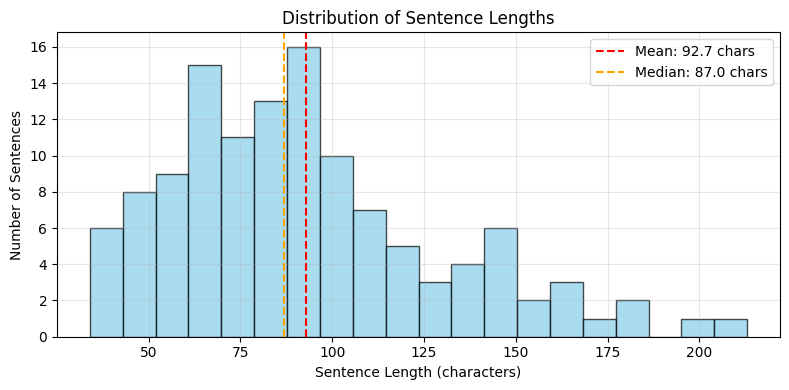

In [ ]:
sentence_lengths = [len(sent) for sent in final_sentences]

plt.figure(figsize=(8, 4))
plt.hist(sentence_lengths, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(np.mean(sentence_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(sentence_lengths):.1f} chars')
plt.axvline(np.median(sentence_lengths), color='orange', linestyle='--', label=f'Median: {np.median(sentence_lengths):.1f} chars')

plt.xlabel('Sentence Length (characters)')
plt.ylabel('Number of Sentences')
plt.title('Distribution of Sentence Lengths')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**SECTION 8a: WORD-LEVEL STATISTICS**

Tokenises the cleaned corpus (via NLTK word_tokenize) and computes:
   - total word count, unique word count
   - lexical diversity (total / unique – inverse of TTR)
   - average word length in characters
   - per-length bucket counts (1-char words, 2-char words, ...)
   - top-10 longest unique word forms


In [ ]:
filtered_text = ' '.join(final_sentences)
words = word_tokenize(filtered_text)
words = [word for word in words if word.strip()]

print(f"Total words: {len(words)}")
print(f"Number of unique words: {len(set(words))}")
print(f"Lexical diversity: {len(words)/len(set(words)):.2f}")


total_characters = sum(len(word) for word in words)
average_word_length = total_characters / len(words)
print(f"Average word length: {average_word_length:.2f} characters")

print(f"\nWord Length Distribution:")
word_lengths = [len(word) for word in words]
max_length = max(word_lengths)
for length in range(1, max_length + 1):
    count = word_lengths.count(length)
    if count > 0:
        percentage = (count / len(words)) * 100
        print(f"  {length} characters: {count} words ({percentage:.1f}%)")

print(f"\nTop 10 Longest Unique Words:")
unique_words_sorted = sorted(set(words), key=lambda x: len(x), reverse=True)
for i, word in enumerate(unique_words_sorted[:10], 1):
    print(f"  {i}. {word} ({len(word)} characters)")

Total words: 2009
Number of unique words: 765
Lexical diversity: 2.63
Average word length: 4.88 characters

Word Length Distribution:
  1 characters: 330 words (16.4%)
  2 characters: 246 words (12.2%)
  3 characters: 211 words (10.5%)
  4 characters: 268 words (13.3%)
  5 characters: 191 words (9.5%)
  6 characters: 144 words (7.2%)
  7 characters: 172 words (8.6%)
  8 characters: 186 words (9.3%)
  9 characters: 77 words (3.8%)
  10 characters: 73 words (3.6%)
  11 characters: 52 words (2.6%)
  12 characters: 28 words (1.4%)
  13 characters: 13 words (0.6%)
  14 characters: 11 words (0.5%)
  15 characters: 6 words (0.3%)
  17 characters: 1 words (0.0%)

Top 10 Longest Unique Words:
  1. viewing/listening (17 characters)
  2. Hyperparameters (15 characters)
  3. hyperparameters (15 characters)
  4. Personalization (15 characters)
  5. improves—making (15 characters)
  6. recommendations (15 characters)
  7. Classification (14 characters)
  8. dimensionality (14 characters)
  9. classi

**SECTION 8b: WORD LENGTH DISTRIBUTION (CHART)**

Plots a histogram of individual word lengths with mean / median markers.


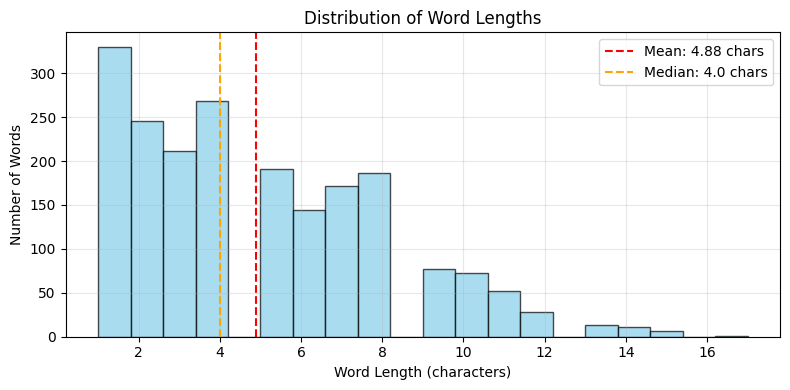

In [ ]:
word_lengths = [len(word) for word in words]

plt.figure(figsize=(8, 4))
plt.hist(word_lengths, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(np.mean(word_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(word_lengths):.2f} chars')
plt.axvline(np.median(word_lengths), color='orange', linestyle='--', label=f'Median: {np.median(word_lengths):.1f} chars')

plt.xlabel('Word Length (characters)')
plt.ylabel('Number of Words')
plt.title('Distribution of Word Lengths')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**SECTION 8c: TOP-20 CONTENT WORDS (STOPWORDS REMOVED)**

Removes English stopwords with NLTK, builds a FreqDist, and prints the
20 most frequent content words.  

These frequent terms also drive the
are_related() relatedness check used during sentence merging.


In [ ]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

content_words = [word.lower() for word in words if word.isalpha() and word.lower() not in stop_words]
word_freq = FreqDist(content_words)

print("\n Top 20 most common words:")
for word, count in word_freq.most_common(20):
    print(f"  {word}: {count}")


 Top 20 most common words:
  data: 39
  learning: 37
  model: 23
  examples: 14
  ml: 12
  machine: 12
  example: 12
  new: 11
  based: 11
  models: 10
  systems: 9
  learn: 8
  time: 8
  real: 8
  key: 8
  supervised: 8
  input: 7
  complex: 7
  like: 7
  spam: 7


**SECTION 8d: TOP-20 CONTENT WORDS – HORIZONTAL BAR CHART**

Visualises the frequency of the top-20 content words as a horizontal bar chart with frequency labels at the end of each bar.


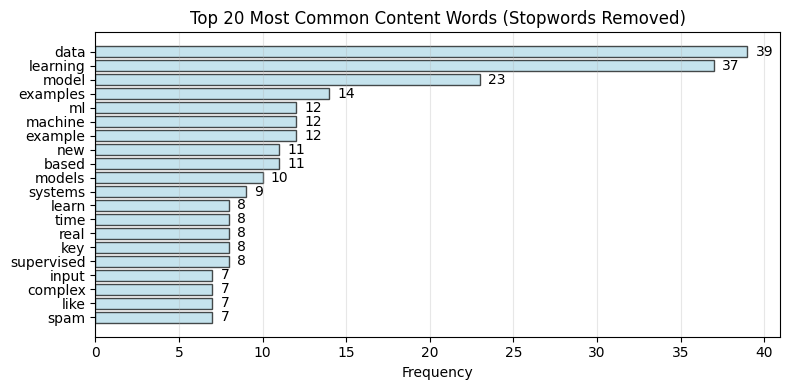

In [ ]:
top_20_common = word_freq.most_common(20)
words_list, counts = zip(*top_20_common)

plt.figure(figsize=(8, 4))
bars = plt.barh(range(len(words_list)), counts, color='lightblue', alpha=0.7, edgecolor='black')
plt.yticks(range(len(words_list)), words_list)
plt.xlabel('Frequency')
plt.title('Top 20 Most Common Content Words (Stopwords Removed)')
plt.gca().invert_yaxis()

for i, (bar, count) in enumerate(zip(bars, counts)):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{count}', va='center', ha='left')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**SECTION 8e: TOP-10 WORD PAIRS (BIGRAMS)**

Uses NLTK's bigrams() utility to form all consecutive content-word pairs,
counts their frequency with FreqDist, and prints the top-10 most common.

Frequent bigrams (e.g. 'machine learning', 'supervised learning') reveal
the core vocabulary of the source document.


In [ ]:
from nltk import bigrams
bigrams_list = list(bigrams(content_words))
bigram_freq = FreqDist(bigrams_list)

print(f"\n Top 10 most common word pairs:")
for (word1, word2), count in bigram_freq.most_common(10):
    print(f"  {word1} {word2}: {count}")


 Top 10 most common word pairs:
  machine learning: 12
  new data: 7
  supervised learning: 7
  real time: 5
  unsupervised learning: 5
  key idea: 4
  based learning: 4
  dimensionality reduction: 4
  real world: 3
  learn data: 3


**SECTION 8f: TOP-10 BIGRAMS – HORIZONTAL BAR CHART**

Visualises bigram frequencies as a horizontal bar chart.


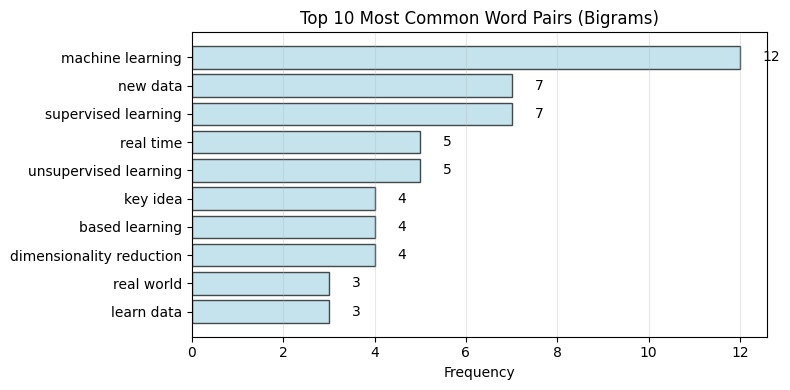

In [ ]:
top_10_bigrams = bigram_freq.most_common(10)
bigram_pairs = [f"{word1} {word2}" for (word1, word2), count in top_10_bigrams]
counts = [count for (word1, word2), count in top_10_bigrams]

plt.figure(figsize=(8, 4))
bars = plt.barh(range(len(bigram_pairs)), counts, color='lightblue', alpha=0.7, edgecolor='black')
plt.yticks(range(len(bigram_pairs)), bigram_pairs)
plt.xlabel('Frequency')
plt.title('Top 10 Most Common Word Pairs (Bigrams)')
plt.gca().invert_yaxis()

for i, (bar, count) in enumerate(zip(bars, counts)):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{count}', va='center', ha='left')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**USING BERT FOR QUESTION-ANSWER PAIRS GENERATION**

**SECTION 9a: ADVANCED CONCEPT EXTRACTION  (spaCy-based)**

    advanced_concept_extraction(sentence)

   Extracts the most salient concept phrase from a sentence using three
   complementary strategies:

   1. Syntactic dependency analysis
      Finds the root VERB of the sentence and looks for its direct object
      (dobj / attr / pobj) or subject (nsubj / nsubjpass) that is a NOUN
      or PROPN.  Objects are preferred over subjects.

   2. Named Entity Recognition (NER)
      Collects all entities labelled ORG, PRODUCT, or EVENT.

   3. Noun-chunk extraction
      Collects all noun phrases 1–3 words long.

   Scoring heuristic (higher = better candidate):

  - +3  multi-word phrase
  - +2  appears in the first 30 % of the sentence (topic position)
  - +2  contains a domain-specific technical term
  - +1  not a generic stop-concept ('introduction', 'we', 'this', ...)

   Returns the top-scoring concept string if its score > 2, else None.


In [ ]:
def advanced_concept_extraction(sentence):
    doc = nlp(sentence)

    concepts = []

    for token in doc:
        if token.dep_ == "ROOT" and token.pos_ == "VERB":
            subject = None
            obj = None

            for child in token.children:
                if child.dep_ in ["nsubj", "nsubjpass"]:
                    subject = child
                elif child.dep_ in ["dobj", "attr", "pobj"]:
                    obj = child

            if obj and obj.pos_ in ["NOUN", "PROPN"]:
                concepts.append(obj.text)
            elif subject and subject.pos_ in ["NOUN", "PROPN"]:
                concepts.append(subject.text)

    entities = [ent.text for ent in doc.ents if ent.label_ in ["ORG", "PRODUCT", "EVENT"]]
    noun_phrases = [chunk.text for chunk in doc.noun_chunks if 1 <= len(chunk.text.split()) <= 3]

    concepts.extend(entities)
    concepts.extend(noun_phrases)

    if concepts:
        scored_concepts = []

        for concept in concepts:
            score = 0

            if len(concept.split()) > 1:
                score += 3

            concept_position = sentence.lower().find(concept.lower())
            if concept_position < len(sentence) * 0.3:
                score += 2

            technical_terms = ['generation', 'layer', 'algorithm', 'structure', 'system', 'computer', 'programming']
            if any(term in concept.lower() for term in technical_terms):
                score += 2

            generic_terms = ['introduction', 'example', 'we', 'you', 'they', 'this', 'that']
            if not any(term in concept.lower() for term in generic_terms):
                score += 1

            scored_concepts.append((concept, score))

        best_concept = max(scored_concepts, key=lambda x: x[1])
        return best_concept[0] if best_concept[1] > 2 else None

    return None

**SECTION 9b: SEMANTIC QUESTION GENERATION**

    semantic_question_generation(sentence, concept)

   Selects an appropriate question template based on the semantic content of
   the sentence:

   - Definition  → "What is <concept>?"
   - Usage       → "What is <concept> used for?"
   - Process     → "How does <concept> work?"
   - Comparison  → "How does <concept> differ from others?"
   - 'generation' in concept → "What characterizes the <concept>?"
   - 'layer' in concept      → "What is the function of the <concept>?"
   - Default     → "What is <concept>?"

   Detection is performed by lemmatising key verbs in the sentence (define,
   mean, refer, use, utilise, employ, work, operate, function, compare,
   versus, vs).


In [ ]:
def semantic_question_generation(sentence, concept):
    doc = nlp(sentence)

    has_definition = any(token.lemma_ in ['define', 'mean', 'refer'] for token in doc)
    has_usage = any(token.lemma_ in ['use', 'utilize', 'employ'] for token in doc)
    has_process = any(token.lemma_ in ['work', 'operate', 'function'] for token in doc)
    has_comparison = any(token.lemma_ in ['compare', 'versus', 'vs'] for token in doc)

    if has_definition:
        return f"What is {concept}?"
    elif has_usage:
        return f"What is {concept} used for?"
    elif has_process:
        return f"How does {concept} work?"
    elif has_comparison:
        return f"How does {concept} differ from others?"
    elif 'generation' in concept.lower():
        return f"What characterizes the {concept}?"
    elif 'layer' in concept.lower():
        return f"What is the function of the {concept}?"
    else:
        return f"What is {concept}?"

**SECTION 9c: SEMANTIC ANSWER EXTRACTION**

    extract_semantic_answer(sentence, concept, question)

  Attempts to extract the most informative answer span from the sentence:

  Strategy 1 – Dependency-based extraction:

  * Locates the token that aligns with the concept position in the sentence,
  identifies its governing VERB, then collects all direct objects /
  attributes / prepositional objects of that verb to form the answer phrase.

   Strategy 2 – String-split fallback:

  * If strategy 1 yields nothing, splits on the first occurrence of the
  concept string and returns the text that follows up to the first
  sentence terminator.

   If neither strategy succeeds, the concept string itself is returned as a
   last-resort answer.


In [ ]:
def extract_semantic_answer(sentence, concept, question):
    doc = nlp(sentence)

    concept_start = sentence.lower().find(concept.lower())
    if concept_start == -1:
        return concept

    governing_verb = None
    for token in doc:
        if (token.idx <= concept_start <= token.idx + len(token.text) and
            token.head.pos_ == "VERB"):
            governing_verb = token.head
            break

    if governing_verb:
        verb_phrase = []
        for child in governing_verb.children:
            if child.dep_ in ["dobj", "attr", "acomp", "prep"]:
                subtree = [t.text for t in child.subtree]
                verb_phrase.extend(subtree)

        if verb_phrase:
            answer = " ".join([governing_verb.text] + verb_phrase)
            answer = re.sub(r'[^\w\s]', '', answer)
            return answer.strip()

    parts = sentence.split(concept, 1)
    if len(parts) > 1:
        answer = parts[1].strip()
        answer = re.sub(r'^[^\w]*', '', answer)
        answer = re.split(r'[.!?]', answer)[0]
        return answer.strip()

    return concept

**SECTION 9d: QA GENERATION ORCHESTRATOR**

    nlp_qa_generation(sentences)

   Iterates over every sentence in *sentences* and produces one QA pair per
   sentence (if a suitable concept can be found):

   For each sentence:

1. Call advanced_concept_extraction() to find the key concept.
  Skip the sentence if no concept is found.
2. Call semantic_question_generation() to create a question.
3. Call extract_semantic_answer() to extract the answer.
4. Truncate the answer to 12 words (add '...' if longer).
5. Append a dict with keys:

  - 'sentence'  – source sentence
  - 'concept'   – extracted concept
  - 'question'  – generated question
  - 'answer'    – extracted answer
  - 'method'    – always 'advanced-nlp'

   Returns the list of QA pair dicts.


In [ ]:
def nlp_qa_generation(sentences):
    qa_pairs = []

    for i, sentence in enumerate(sentences):

        print(f"\nProcessing: {sentence}...")

        concept = advanced_concept_extraction(sentence)
        if not concept:
            print("  No suitable concept found with advanced NLP")
            continue

        print(f"  Concept: {concept}")

        question = semantic_question_generation(sentence, concept)

        answer = extract_semantic_answer(sentence, concept, question)

        answer = re.sub(r'\s+', ' ', answer).strip()
        if len(answer.split()) > 12:
            answer = ' '.join(answer.split()[:12]) + '...'

        qa_pairs.append({
            'sentence': sentence,
            'concept': concept,
            'question': question,
            'answer': answer,
            'method': 'advanced-nlp'
        })

        print(f"  Q: {question}")
        print(f"  A: {answer}")

    return qa_pairs

**SECTION 10: RUN QA GENERATION & PRINT RESULTS**

Calls nlp_qa_generation() on the cleaned sentence corpus and prints every
generated QA pair together with the source concept, method tag, and the
originating sentence.


In [ ]:
nlp_qa_pairs = nlp_qa_generation(final_sentences)

print(f"\n Generated {len(nlp_qa_pairs)} QA pairs using advanced NLP!")
print("\n" + "-"*80)

for i, qa in enumerate(nlp_qa_pairs, 1):
    print(f"\n{i}. QUESTION: {qa['question']}")
    print(f"   ANSWER: {qa['answer']}")
    print(f"   CONCEPT: {qa['concept']}")
    print(f"   METHOD: {qa['method']}")
    print(f"   SOURCE: {qa['sentence']}...")
    print("-" * 80)


Processing: Unlike traditional programming, which follows the logic: input + rules = output, ml uses input + output examples to learn rules, which can then be applied to new data....
  Concept: traditional programming
  Q: What is traditional programming used for?
  A: which follows the logic: input + rules = output, ml uses input...

Processing: His checkers playing program exemplified this idea....
  Concept: His checkers
  Q: What is His checkers?
  A: playing program exemplified this idea

Processing: Instead of giving them rules to identify animals, you show them many labeled pictures....
  Concept: many labeled pictures
  Q: What is many labeled pictures?
  A: 

Processing: Over time, they learn to recognize cats, dogs, and birds without needing an explicit rulebook....
  Concept: an explicit rulebook
  Q: What is an explicit rulebook?
  A: 

Processing: Machine learning (ml) is increasingly relied upon because it can solve complex problems that traditional rule based programmin

**ANALYSIS**

**SECTION 11a: MODEL PERFORMANCE METRICS**

Three automatic quality metrics are computed:

 1. Coverage Rate
    = (# QA pairs generated) / (# input sentences) × 100
    
    Measures how many sentences successfully yielded a QA pair.
    A high coverage rate indicates that the concept extractor seldom fails.

 2. Concept Precision
    = (# questions that contain the extracted concept string) / (# QA pairs) × 100
    
    Checks that the generated question actually references the concept.
    Should be 100 % by construction given the templates used.

 3. Grammatical Quality (requires LanguageTool Java runtime)
    
    For each generated question, LanguageTool is used to count grammatical
    errors.  
    
    Scores are assigned:
    0 errors  → 1.0,
    1–2 errors → 0.5, > 2 errors  → 0.0

    The average across all questions is reported.
    
    If LanguageTool is unavailable the metric is gracefully skipped.


In [ ]:
total_input_sentences = len(final_sentences)
coverage_percentage = (len(nlp_qa_pairs) / total_input_sentences) * 100

print(f"\nCOVERAGE METRICS:")
print(f"   - Generated QA pairs: {len(nlp_qa_pairs)}/{total_input_sentences}")
print(f"   - Coverage rate: {coverage_percentage:.1f}%")

concept_in_question = 0
concept_in_answer = 0

for qa in nlp_qa_pairs:
    concept = qa['concept'].lower()
    question = qa['question'].lower()

    if concept in question:
        concept_in_question += 1

concept_question_precision = (concept_in_question / len(nlp_qa_pairs)) * 100

print(f"\nCONCEPT PRECISION:")
print(f"   - Concept appears in question: {concept_question_precision:.1f}%")

try:
    tool = language_tool_python.LanguageTool('en-US')
    grammatical_scores = []

    for qa in nlp_qa_pairs:
        question = qa['question']
        matches = tool.check(question)
        error_count = len(matches)

        if error_count == 0:
            grammatical_scores.append(1.0)
        elif error_count <= 2:
            grammatical_scores.append(0.5)
        else:
            grammatical_scores.append(0.0)

    avg_grammaticality = sum(grammatical_scores) / len(grammatical_scores)
    print(f"\nGRAMMATICAL QUALITY:")
    print(f"   - Average grammatical score: {avg_grammaticality:.2f}/1.0")

except Exception as e:
    print(f"\nGRAMMATICAL QUALITY: Skipped (LanguageTool not available: {e})")


COVERAGE METRICS:
   - Generated QA pairs: 120/123
   - Coverage rate: 97.6%

CONCEPT PRECISION:
   - Concept appears in question: 100.0%



GRAMMATICAL QUALITY:
   - Average grammatical score: 0.95/1.0


**SECTION 11b: PERFORMANCE METRICS – BAR CHART**

Visualises Coverage Rate, Concept Precision and (if available) Grammatical Quality as a grouped vertical bar chart with score labels.


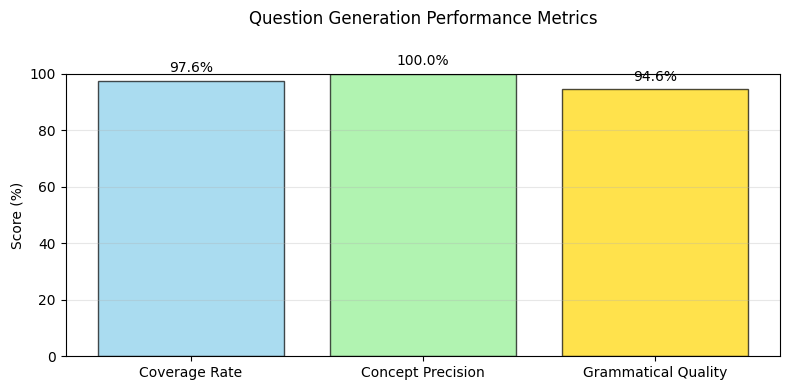

In [ ]:
plt.figure(figsize=(8, 4))

metrics = ['Coverage Rate', 'Concept Precision']
scores = [coverage_percentage, concept_question_precision]

if 'avg_grammaticality' in locals():
    metrics.append('Grammatical Quality')
    scores.append(avg_grammaticality * 100)

bars = plt.bar(metrics, scores, color=['skyblue', 'lightgreen', 'gold'][:len(metrics)],
               alpha=0.7, edgecolor='black')

plt.ylabel('Score (%)')
plt.title('Question Generation Performance Metrics\n\n')
plt.ylim(0, 100)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{score:.1f}%', ha='center', va='bottom')

plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**SECTION 12a: QUESTION TYPE DISTRIBUTION**

Classifies every generated question into one of the template types defined
in semantic_question_generation() using regex matching:

   - 'What is.*used for', 'What is', 'How does', 'What characterizes',
   - 'What is the function', or 'Other'.

 Prints the count and percentage for each type.


In [ ]:
question_types = []
question_patterns = {
    'What is': r'^What is',
    'How does': r'^How does',
    'What characterizes': r'^What characterizes',
    'What is the function': r'^What is the function',
    'What is.*used for': r'What is.*used for'
}

for qa in nlp_qa_pairs:
    question = qa['question']
    matched = False
    for q_type, pattern in question_patterns.items():
        if re.search(pattern, question, re.IGNORECASE):
            question_types.append(q_type)
            matched = True
            break
    if not matched:
        question_types.append('Other')

type_distribution = Counter(question_types)

print(f"\nQUESTION TYPE DISTRIBUTION:")
for q_type, count in type_distribution.most_common():
    percentage = (count / len(nlp_qa_pairs)) * 100
    print(f"   - {q_type}: {count} ({percentage:.1f}%)")


QUESTION TYPE DISTRIBUTION:
   - What is: 115 (95.8%)
   - How does: 5 (4.2%)


**SECTION 12b: QUESTION TYPE DISTRIBUTION – PIE CHART**

Visualises the question-type distribution as a pie chart.


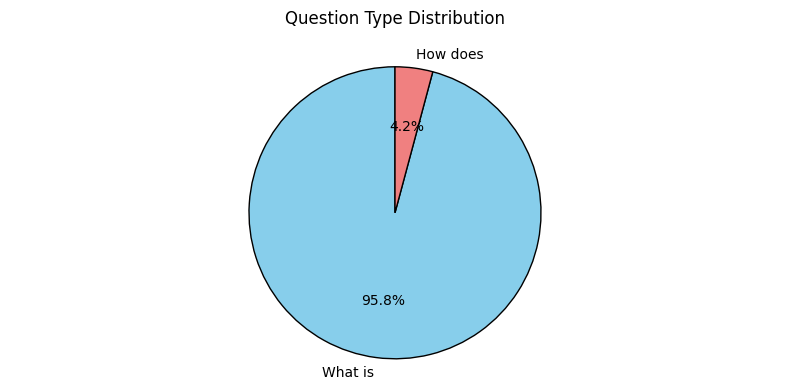

In [ ]:
plt.figure(figsize=(8, 4))
labels = list(type_distribution.keys())
sizes = list(type_distribution.values())

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'lightpurple', 'lightcyan'][:len(labels)],
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})

plt.title('Question Type Distribution\n')
plt.axis('equal')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**SECTION 13a: ANSWER LENGTH ANALYSIS**

Computes the word-count of every generated answer and reports:
   - average answer length in words
   - number of empty answers (extraction failed)
   - min / max answer word count


In [ ]:
answer_lengths = []
empty_answers = 0

for qa in nlp_qa_pairs:
    answer = qa['answer'].strip()
    if not answer or answer == '':
        empty_answers += 1
        answer_lengths.append(0)
    else:
        word_count = len(answer.split())
        answer_lengths.append(word_count)

avg_answer_length = sum(answer_lengths) / len(answer_lengths)

print(f"\nANSWER LENGTH ANALYSIS:")
print(f"   - Average answer length: {avg_answer_length:.1f} words")
print(f"   - Empty answers: {empty_answers}")
print(f"   - Answer length range: {min(answer_lengths)} to {max(answer_lengths)} words")


ANSWER LENGTH ANALYSIS:
   - Average answer length: 8.1 words
   - Empty answers: 3
   - Answer length range: 0 to 12 words


**SECTION 13b: ANSWER LENGTH DISTRIBUTION – HISTOGRAM**

Plots the distribution of answer lengths (in words) with a mean marker.


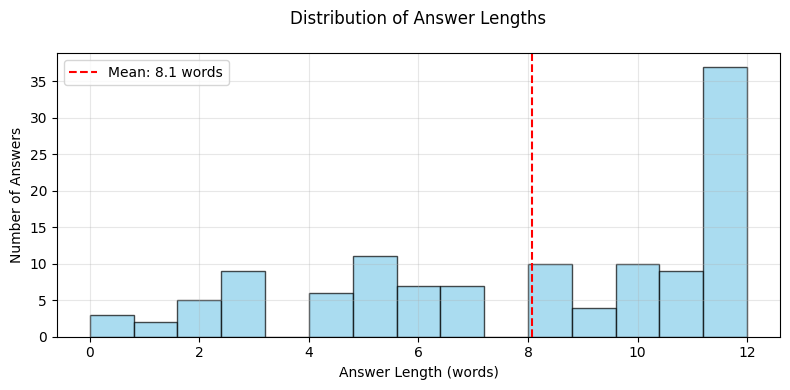

In [ ]:
plt.figure(figsize=(8, 4))

plt.hist(answer_lengths, bins=15, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(np.mean(answer_lengths), color='red', linestyle='--',
            label=f'Mean: {np.mean(answer_lengths):.1f} words')

plt.xlabel('Answer Length (words)')
plt.ylabel('Number of Answers')
plt.title('Distribution of Answer Lengths\n')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**SECTION 14: FAILURE ANALYSIS**

Automatically detects potentially problematic QA pairs and flags them:
   - Very short answers (≤2 words) may indicate extraction failure.
   - Concept string absent from the question indicates a template mismatch.

 Prints each flagged pair with the question and extracted answer so that the
 developer can manually inspect and improve the pipeline.


In [ ]:
print(f"\nFAILURE ANALYSIS:")

problematic_pairs = []
for i, qa in enumerate(nlp_qa_pairs):
    answer_words = len(qa['answer'].split())
    if answer_words <= 2:
        problematic_pairs.append((i, qa, f"Short answer ({answer_words} words)"))
    elif qa['concept'].lower() not in qa['question'].lower():
        problematic_pairs.append((i, qa, "Concept missing from question"))

if problematic_pairs:
    print(f"   - Found {len(problematic_pairs)} potentially problematic QA pairs:")
    for idx, qa, issue in problematic_pairs:
        print(f"     #{idx+1}: {issue}")
        print(f"       Q: {qa['question']}")
        print(f"       A: {qa['answer']}")
else:
    print("   - No major issues detected automatically")


FAILURE ANALYSIS:
   - Found 10 potentially problematic QA pairs:
     #3: Short answer (0 words)
       Q: What is many labeled pictures?
       A: 
     #4: Short answer (0 words)
       Q: What is an explicit rulebook?
       A: 
     #25: Short answer (2 words)
       Q: What is what?
       A: watched what
     #34: Short answer (2 words)
       Q: What is customer segmentation?
       A: in marketing
     #36: Short answer (2 words)
       Q: What is labeling data?
       A: is expensive
     #48: Short answer (1 words)
       Q: What is real time?
       A: environments
     #55: Short answer (0 words)
       Q: What is real time?
       A: 
     #74: Short answer (1 words)
       Q: What is similar data points?
       A: together
     #79: Short answer (2 words)
       Q: What is hidden groupings?
       A: in data
     #106: Short answer (2 words)
       Q: What is What?
       A: are hyperparameters


**SECTION 15: QUESTION LENGTH vs ANSWER LENGTH (SCATTER PLOT)**

Scatter plot of question word count (x-axis) against answer word count
 (y-axis), with a linear regression trend line.

 A flat or slightly positive trend is expected because the answer length is
 capped at 12 words regardless of the question complexity.


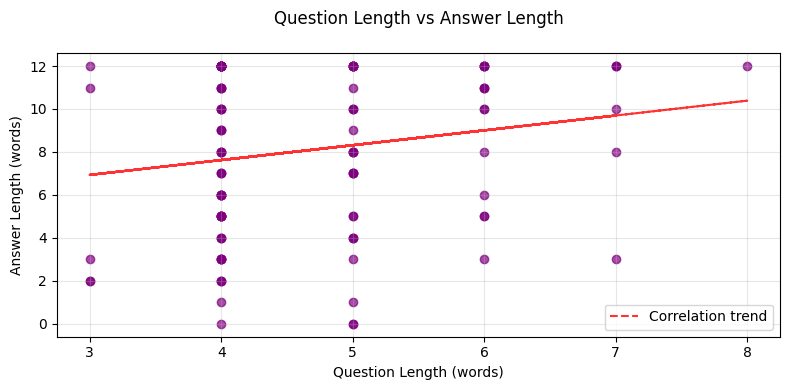

In [ ]:
plt.figure(figsize=(8, 4))

question_lengths = [len(qa['question'].split()) for qa in nlp_qa_pairs]
answer_lengths = [len(qa['answer'].split()) for qa in nlp_qa_pairs]

plt.scatter(question_lengths, answer_lengths, alpha=0.7, color='purple')

z = np.polyfit(question_lengths, answer_lengths, 1)
p = np.poly1d(z)
plt.plot(question_lengths, p(question_lengths), "r--", alpha=0.8, label='Correlation trend')

plt.xlabel('Question Length (words)')
plt.ylabel('Answer Length (words)')
plt.title('Question Length vs Answer Length\n')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**SUMMARY**


*   dependencies
*   cleaned data (number of pages, text before and after cleaning)
_________________________________________________________________________

*   total sentences found
*   average sentence length
*   longest sentence length
*   shortest sentence length
*   5 longest sentences
*   Distribution of Sentence Length - chart

_________________________________________________________________________

*   total words
*   number of unique words
*   lexical diversity
*   average word length
*   word lenght distribution + chart
*   top 10 longest unique words
*   top 20 most common words + chart
*   top 10 most common word pairs + chart
_________________________________________________________________________

*   cleaned dataset sentences
_________________________________________________________________________
*   concept extraction
*   question generation
*   answer extraction
_________________________________________________________________________
*   Question-Answer Pairs
_________________________________________________________________________
*   NLP quality analysis

